In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier

url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)

In [2]:
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
for x in cols_with_zeros:
    print('La colonna',x,'ha',(df[x]==0).sum(),'zeri')

La colonna Glucose ha 5 zeri
La colonna BloodPressure ha 35 zeri
La colonna SkinThickness ha 227 zeri
La colonna Insulin ha 374 zeri
La colonna BMI ha 11 zeri


In [5]:
for x in cols_with_zeros:
    df[x] = df[x].replace(0,np.nan)

In [6]:
for x in cols_with_zeros:
    print('La colonna',x,'ha',df[x].isnull().sum(),'valori nulli')

La colonna Glucose ha 5 valori nulli
La colonna BloodPressure ha 35 valori nulli
La colonna SkinThickness ha 227 valori nulli
La colonna Insulin ha 374 valori nulli
La colonna BMI ha 11 valori nulli


In [13]:
for col in cols_with_zeros:
    df[col] = df.groupby('Outcome')[col].transform(lambda x: x.fillna(x.median()))

In [14]:
for x in cols_with_zeros:
    print('La colonna',x,'ha',df[x].isnull().sum(),'valori nulli')

La colonna Glucose ha 0 valori nulli
La colonna BloodPressure ha 0 valori nulli
La colonna SkinThickness ha 0 valori nulli
La colonna Insulin ha 0 valori nulli
La colonna BMI ha 0 valori nulli


In [15]:
x = df.drop('Outcome',axis = 1)
print(x.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0    169.5  33.6   
1            1     85.0           66.0           29.0    102.5  26.6   
2            8    183.0           64.0           32.0    169.5  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  


In [16]:
y = df['Outcome']
print(y)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


In [17]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [18]:
scaler = StandardScaler()
scaler.fit(x_train)

x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

In [19]:
model = GradientBoostingClassifier()
model.fit(x_train,y_train)

y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.8701298701298701


In [20]:
y_pred_prob = model.predict_proba(x_test)[:,1]

roc_auc = roc_auc_score(y_test,y_pred_prob)

print(roc_auc)

0.9368227731864095


In [21]:
## cross validation

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

In [22]:
pipe = Pipeline([
    ('scaler',StandardScaler()),
    ('model',GradientBoostingClassifier(random_state=42))
]) 

In [23]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [24]:
scores = cross_val_score(pipe,x,y,cv=cv,scoring='roc_auc')

In [25]:
print(scores.round(3))

[0.938 0.954 0.941 0.962 0.962]


In [26]:
print(scores.mean().round(3),scores.std().round(3))

0.951 0.01


In [27]:
## metriche

from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score
from sklearn.metrics import precision_recall_curve

In [28]:
pipe.fit(x_train,y_train)
y_pred = pipe.predict(x_test)
y_proba = pipe.predict_proba(x_test)[:,1]

In [29]:
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
avg_precision = average_precision_score(y_test,y_proba)

print(f'la precision è:',precision,'\n la recall è:',recall,"\n l'F1 score è:", f1,"\n l'average precision score è:",avg_precision)

la precision è: 0.8070175438596491 
 la recall è: 0.8363636363636363 
 l'F1 score è: 0.8214285714285714 
 l'average precision score è: 0.899232601188154


In [30]:
print(precision_recall_curve(y_test,y_proba))

(array([0.35714286, 0.35947712, 0.36184211, 0.36423841, 0.36666667,
       0.36912752, 0.37162162, 0.37414966, 0.37671233, 0.37931034,
       0.38194444, 0.38461538, 0.38732394, 0.39007092, 0.39285714,
       0.39568345, 0.39855072, 0.40145985, 0.40441176, 0.40740741,
       0.41044776, 0.41353383, 0.41666667, 0.41984733, 0.42307692,
       0.42635659, 0.4296875 , 0.43307087, 0.43650794, 0.44      ,
       0.44354839, 0.44715447, 0.45081967, 0.44628099, 0.45      ,
       0.45378151, 0.45762712, 0.46153846, 0.46551724, 0.46956522,
       0.47368421, 0.47787611, 0.48214286, 0.48648649, 0.49090909,
       0.49541284, 0.5       , 0.5046729 , 0.50943396, 0.51428571,
       0.51923077, 0.52427184, 0.52941176, 0.52475248, 0.53      ,
       0.52525253, 0.53061224, 0.53608247, 0.54166667, 0.54736842,
       0.55319149, 0.55913978, 0.56521739, 0.57142857, 0.57777778,
       0.58426966, 0.59090909, 0.59770115, 0.60465116, 0.61176471,
       0.61904762, 0.62650602, 0.63414634, 0.64197531, 0.65  

In [31]:
precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, y_proba)

In [32]:
import matplotlib.pyplot as plt

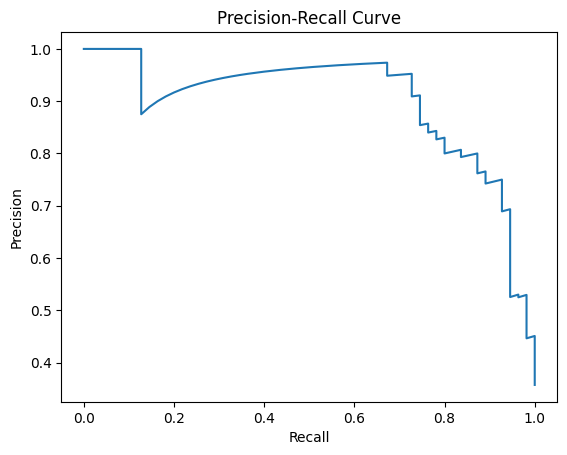

In [33]:
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.plot(recall_curve,precision_curve)

In [71]:
## gestione classi sbilanciate

!pip install -U scikit-learn imbalanced-learn

  Using cached scikit_learn-1.9.0-cp312-cp312-win_amd64.whl.metadata (11 kB)


In [35]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

In [36]:
x_train_smote,y_train_smote = smote.fit_resample(x_train,y_train)


In [37]:
y_train_smote.value_counts()

Outcome
0    401
1    401
Name: count, dtype: int64

In [38]:
pipe = Pipeline([
    ('scaler',StandardScaler()),
    ('model',GradientBoostingClassifier(random_state=42))
])

In [39]:
pipe.fit(x_train_smote,y_train_smote)

y_pred = pipe.predict(x_test)
y_pred_proba = pipe.predict_proba(x_test)

In [40]:
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
avg_precision = average_precision_score(y_test,y_proba)

print(f'la precision è:',precision,'\n la recall è:',recall,"\n l'F1 score è:", f1,"\n l'average precision score è:",avg_precision)

la precision è: 0.7868852459016393 
 la recall è: 0.8727272727272727 
 l'F1 score è: 0.8275862068965517 
 l'average precision score è: 0.899232601188154


In [41]:
##threshold tuning

y_new_tresh = np.where(y_proba > 0.3,1,0)

In [42]:
precision = precision_score(y_test,y_new_tresh)
recall = recall_score(y_test,y_new_tresh)
f1 = f1_score(y_test,y_new_tresh)
avg_precision = average_precision_score(y_test,y_proba)

print(f'la precision è:',precision,'\n la recall è:',recall,"\n l'F1 score è:", f1,"\n l'average precision score è:",avg_precision)

la precision è: 0.7619047619047619 
 la recall è: 0.8727272727272727 
 l'F1 score è: 0.8135593220338984 
 l'average precision score è: 0.899232601188154


In [43]:
## calibrazione della probabilità

from sklearn.calibration import CalibratedClassifierCV, calibration_curve

In [46]:
pipe = Pipeline([
    ('scaler',StandardScaler()),
    ('model',GradientBoostingClassifier(random_state=42))
])
calibrated = CalibratedClassifierCV(pipe, cv = 5, method = 'isotonic')

calibrated.fit(x_train,y_train)

y_pred = calibrated.predict(x_test)
y_pred_proba = calibrated.predict_proba(x_test)


In [47]:
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
avg_precision = average_precision_score(y_test,y_proba)

print(f'la precision è:',precision,'\n la recall è:',recall,"\n l'F1 score è:", f1,"\n l'average precision score è:",avg_precision)

la precision è: 0.7796610169491526 
 la recall è: 0.8363636363636363 
 l'F1 score è: 0.8070175438596491 
 l'average precision score è: 0.899232601188154


In [49]:
fraction_of_positives, mean_predicted_value = calibration_curve(y_test,y_proba) 

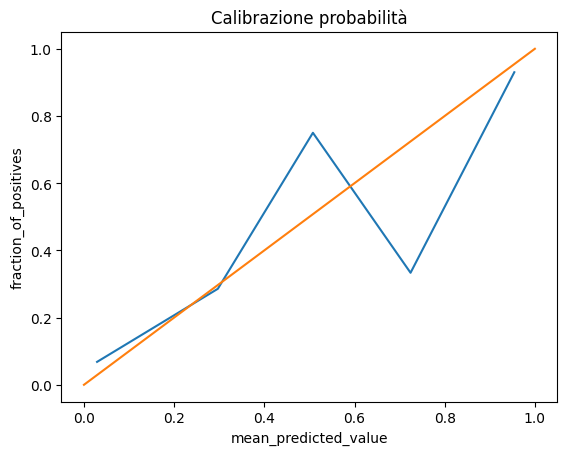

In [57]:
plt.title('Calibrazione probabilità')
plt.xlabel('mean_predicted_value')
plt.ylabel('fraction_of_positives')
plt.plot(mean_predicted_value,fraction_of_positives)
plt.plot([0,1],[0,1])

In [61]:
## SHAP
!pip install shap


   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   -- ------------------------------------- 2.6/38.1 MB 11.6 MB/s eta 0:00:04
   --- ------------------------------------ 3.1/38.1 MB 9.2 MB/s eta 0:00:04
   ---- ----------------------------------- 4.2/38.1 MB 6.4 MB/s eta 0:00:06
   ----- ---------------------------------- 5.0/38.1 MB 5.8 MB/s eta 0:00:06
   ------ --------------------------------- 5.8/38.1 MB 5.4 MB/s eta 0:00:06
   ------ --------------------------------- 5.8/38.1 MB 5.4 MB/s eta 0:00:06
   ------ --------------------------------- 6.6/38.1 MB 4.4 MB/s eta 0:00:08
   ------- -------------------------------- 7.6/38.1 MB 4.6 MB/s eta 0:00:07
   --------- ------------------------------ 8.9/38.1 MB 4.7 MB/s eta 0:00:07
   --------- ------------------------------ 9.4/38.1 MB 4.5 MB/s eta 0:00:07
   ---------- ----------------------------- 10.2/38.1 MB 4.5 MB/s eta 0:00:07
   ----------- ---------------------------- 11.0/38.1 MB 4.4 MB/s eta 0:00:07
   

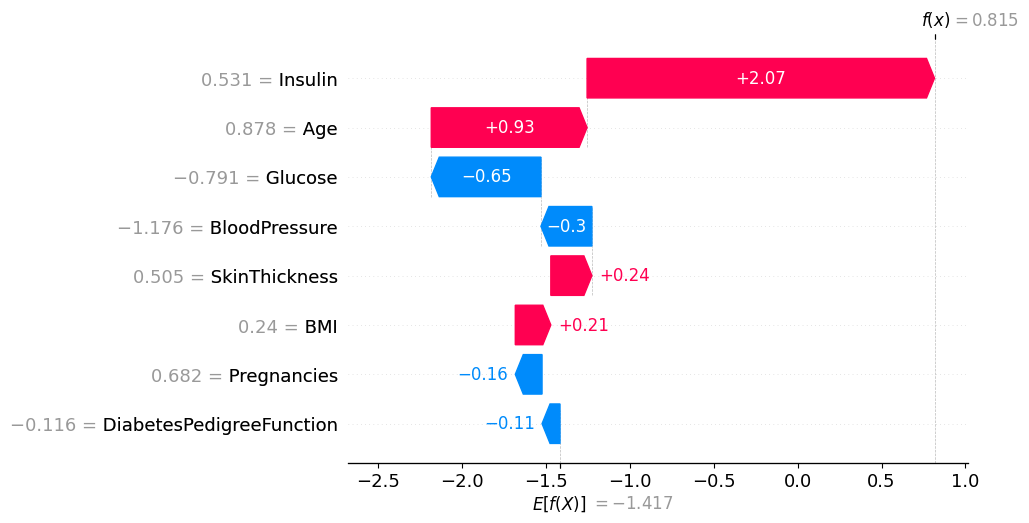

In [69]:
import shap

model = GradientBoostingClassifier(random_state=42)
model.fit(x_train,y_train)


feature_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
explainer = shap.Explainer(model, feature_names=feature_names)
shap_values = explainer(x_test)
shap.plots.waterfall(shap_values[0])

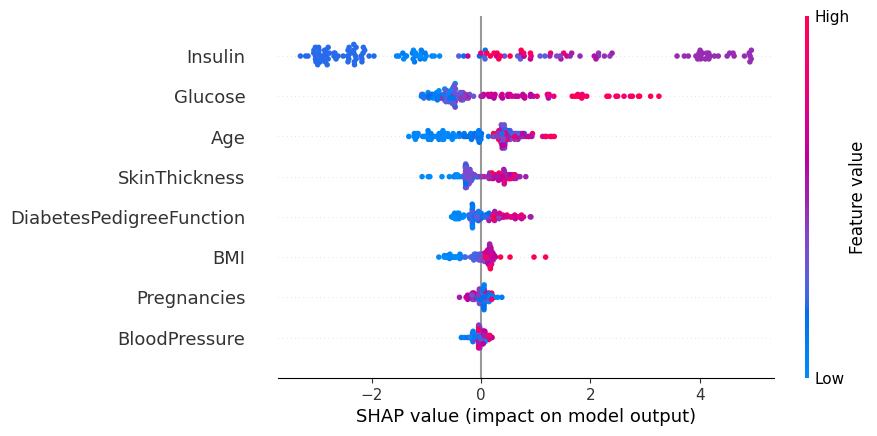

In [70]:
shap.plots.beeswarm(shap_values)